In [2]:
print("hello peter")

hello peter


In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [6]:
#load the iris daatset 
iris = load_iris()

X=iris.data
y=iris.target
print("Feature names:")
print(iris.feature_names)

print("\n Target names:")
print(iris.target_names)

print("\shape of dataset:",X.shape)


Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

 Target names:
['setosa' 'versicolor' 'virginica']
\shape of dataset: (150, 4)


In [13]:
#convert to binary classification 
y_binary =(y!= 0).astype(int)

print("Binary labels:")
print(np.unique(y_binary,return_counts=True))
print(y)


Binary labels:
(array([0, 1]), array([ 50, 100]))
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [21]:
#select two features of visualization 
X_two =X[:,[2,3]]

In [23]:
#split training and testing data 
X_train ,X_test,y_train ,y_test =train_test_split(
    X_two,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

In [26]:
#standardize the Features 
scaler = StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled =scaler.transform(X_test)

In [29]:
#train the linear SVM
linear_svm =SVC(
    kernel ='linear',
    C=1.0
)
linear_svm.fit(X_train_scaled,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [33]:
#make Precitions 
y_pred = linear_svm.predict(X_test_scaled)
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)
print("\nClassification report")
print(classification_report(y_test,y_pred))

Accuracy: 1.0

Classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        20

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



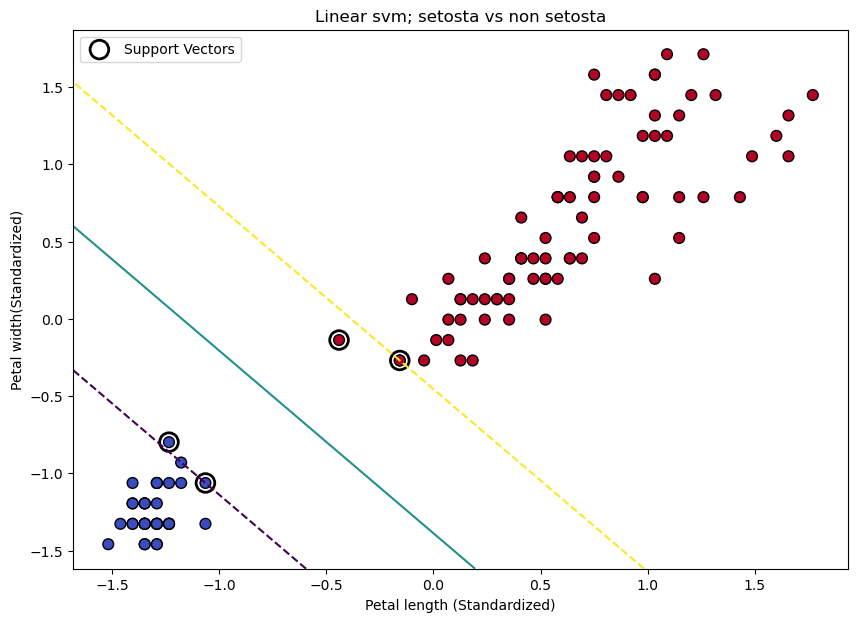

In [40]:
#visualize decision boundry 
plt.figure(figsize=(10,7))

#plot training points
plt.scatter(
   X_train_scaled[:,0],
    X_train_scaled[:,1],
    c=y_train,
    s=60,
    cmap='coolwarm',
    edgecolors='k'

)
  #create grid
ax= plt.gca()
xlim=ax.get_xlim()
ylim=ax.get_ylim()
xx=np.linspace(xlim[0],xlim[1],200)
yy=np.linspace(ylim[0],ylim[1],200)

YY,XX = np.meshgrid(yy,xx)

xy = np.vstack([XX.ravel(),YY.ravel()]).T
#calculate descion function
Z= linear_svm.decision_function(xy)

Z=Z.reshape(XX.shape)
ax.contour(
    XX,
    YY,
    Z,
    levels=[-1,0,1],
    linestyles=['--','-','--']
)

# highlight support vectors
ax.scatter(
    linear_svm.support_vectors_[:,0],
    linear_svm.support_vectors_[:,1],
    s=180,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='Support Vectors'
)
plt.xlabel("Petal length (Standardized)")
plt.ylabel("Petal width(Standardized)")    
plt.title("Linear svm; setosta vs non setosta")

plt.legend()
plt.show()



In [48]:
#use all four features and the orginal three class target 
X_full =iris.data 
y_full = iris.target
X_train_full,X_test_full,y_train_full,y_test_full = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)
#scale the features
scaler_full = StandardScaler()

X_train_full = scaler_full.fit_transform(X_train_full)
X_test_full = scaler_full.transform(X_test_full)

In [50]:
#create a linear ,polynomial and rbf svm models 
models={
    "Linear":SVC(kernel="linear",C=1.0),
    "Polynomial":SVC(kernel="poly",degree=3,C=1.0),
    "RBF":SVC(kernel="rbf",C=1.0,gamma="scale")
}


In [54]:
#train and compare
results={}
for name, model in models.items():
    model.fit(X_train_full,y_train_full)
    y_pred= model.predict(X_test_full)
    accuracy= accuracy_score(y_test_full,y_pred)
    results[name] =accuracy

    print(f"\n{name} Kernel")
    print("-"*30)
    print("Accuracy:",accuracy)
   
    print(
        classification_report(
            y_test_full,
            y_pred,
            target_names=iris.target_names
        )
    )


Linear Kernel
------------------------------
Accuracy: 1.0
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Polynomial Kernel
------------------------------
Accuracy: 0.9
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.77      1.00      0.87        10
   virginica       1.00      0.70      0.82        10

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30


RBF Kernel
------------------------------
Accuracy: 0.9666666666666667
              precision    recall  f1-scor